<a href="https://colab.research.google.com/github/dewith/reinforcement/blob/main/bandits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bandits

Imagine an habit tracker app that has a bot, and the bot has three ways to react 
when you haven't gone to the gym:

- 0 = gentle reminder
- 1 = aggressive push
- 2 = say nothing

Unknown to the agent, each action has some probability of getting you to actually go:

- gentle      → 40%
- aggressive  → 65%
- nothing     → 20%


The app's bot doesn't know those numbers. It has to discover them by trying things.

That's a **multi-armed bandit**. There is no real notion of "state" yet. It just repeatedly asks:

> Which action should I choose?

Then gets a reward:
- went to gym     → reward = 1
- didn't go       → reward = 0


The fundamental tension is:

- **Exploit**: "I currently think aggressive works best, so I'll keep using it."
- vs.
- **Explore**: "But maybe gentle is actually better and I just haven't tried it enough."

In [1]:
import random

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def environment(true_probabilities: list[float], action: int) -> int:
    """Returns reward 1 or 0."""
    probability = true_probabilities[action]
    return 1 if random.random() < probability else 0


def choose_action(n_actions: int, values: list[float], epsilon: float = 0.1) -> tuple[str, int]:
    """Returns an action."""
    # Explore
    if random.random() < epsilon:
        return "Explore", random.randrange(n_actions)

    # Exploit
    return "Exploit", max(range(n_actions), key=lambda a: values[a])


def update(counts: list[int], values: list[float], action: int, reward: int) -> None:
    """Updates counts and values."""
    counts[action] += 1
    n = counts[action]

    # Incremental average
    values[action] += (reward - values[action]) / n


def pprint(values: list[float], action_names: list[str]) -> str:
    """Format values with their action names."""
    return ", ".join(
        f"{action_name}={value:.2f}"
        for action_name, value in zip(action_names, values, strict=True)
    )


def plot_progress(
    history: list[list[float]],
    true_probabilities: list[float],
    action_names: list[str],
) -> None:
    """Plot the estimated reward for each action over time."""
    steps = range(1, len(history) + 1)
    palette = sns.color_palette("deep", len(true_probabilities))
    fig, ax = plt.subplots(figsize=(8, 4), dpi=200)

    for action, (true_probability, color) in enumerate(zip(true_probabilities, palette)):
        estimates = [values_at_step[action] for values_at_step in history]
        sns.lineplot(x=steps, y=estimates, color=color, label=action_names[action], ax=ax)
        ax.axhline(true_probability, color=color, linestyle="--", alpha=0.45)

    ax.set(
        title=f"Reward estimates after {len(history):,} iterations",
        xlabel="Iteration (dashed lines = true rewards)",
        ylabel="Estimated reward",
        ylim=(0, 1),
    )
    ax.legend(title=None, frameon=False, ncol=len(true_probabilities))
    sns.despine()
    plt.tight_layout()
    plt.show()
    plt.close(fig)

Counts: {'gentle': 61, 'aggressive': 909, 'nothing': 30}
True rewards: gentle=0.40, aggressive=0.65, nothing=0.20
Estimated rewards: gentle=0.41, aggressive=0.65, nothing=0.10


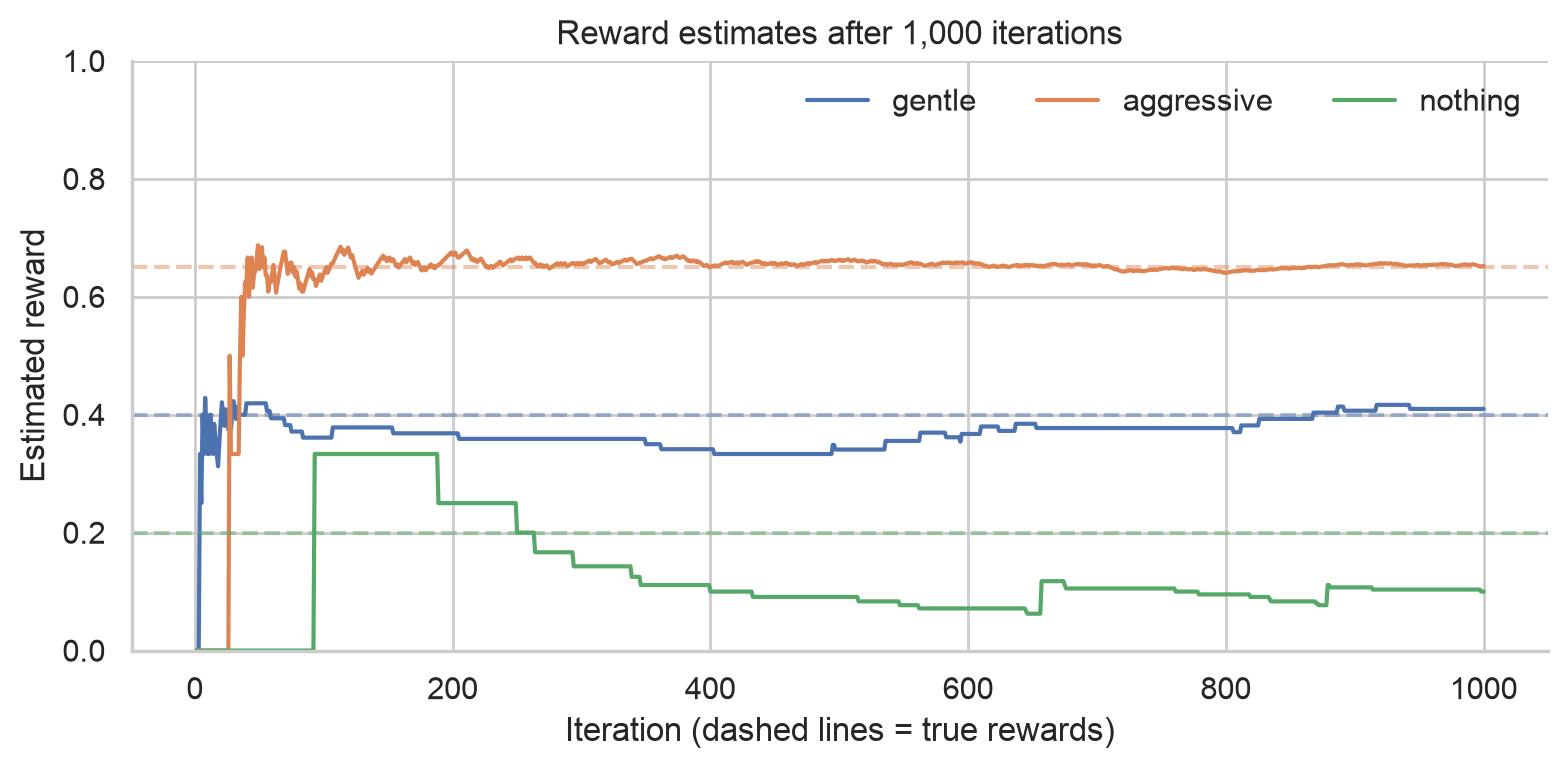

In [3]:
actions = ["gentle", "aggressive", "nothing"]
n_actions = len(actions)

true_probabilities = [0.4, 0.65, 0.2]
counts = [0] * n_actions
values = [0.0] * n_actions
estimate_history = []

n_iters = 1000
for step in range(n_iters):
    _, action = choose_action(n_actions, values, epsilon=0.1)
    reward = environment(true_probabilities, action)
    update(counts, values, action, reward)
    estimate_history.append(values.copy())

print("Counts:", dict(zip(actions, counts, strict=True)))
print("True rewards:", pprint(true_probabilities, actions))
print("Estimated rewards:", pprint(values, actions))

plot_progress(estimate_history, true_probabilities, actions)